# CareWear ECG — Consolidated Analysis

This notebook integrates **every major concept** from the six-notebook workshop into a single, runnable implementation optimized for **CareWear** data.

## Pipeline at a glance

| Stage | What happens |
|---|---|
| **1 — Parsing** | CareWear BIOPAC `.txt` (dynamic header, CH9/CH40) + CareWear belt (extensionless CSV, MAX30003 decode) |
| **2 — Preprocessing matrix** | Three parallel pipelines compared side-by-side |
| **3 — Wavelet visualization** | CWT scalogram + QRS-band energy + reconstruction |
| **4 — Multi-detector comparison** | 9 NeuroKit2 methods + XQRS + PROMAC on each pipeline variant |
| **5 — Beat-level evaluation** | Se / PPV / F1 heatmaps, RR intervals, Bland–Altman |
| **6 — RPNet AI detector** | IncRes-UNet distance transform + adaptive peak picking |
| **7 — Consensus fusion** | BIOPAC-weighted ensemble + SQI-gated final output |

### Preprocessing pipelines compared

| Pipeline | Steps |
|---|---|
| **A — Standard** | Notch → Bandpass (0.5–40 Hz) → Baseline removal |
| **B — SSQ-CWT** | Pipeline A → SSQ-CWT band reconstruction (5–40 Hz) |
| **C — PyWavelets** | Pipeline A → CWT (morlet) QRS-band inverse |

> **Usage:** Set file paths in §1, run all cells. Every plot saves to `outputs/NB00/`.

## 1. Configuration & Imports

In [1]:
# %pip install numpy pandas scipy matplotlib seaborn neurokit2 wfdb tqdm plotly pywt ssqueezepy -q

In [13]:
# =====================================================================
# USER CONFIGURATION
# =====================================================================

CAREWEAR_BIOPAC_FILE_PATH = r"sample_data/CAREWEAR/P27-rest1-biopac-07-02-2025.txt"
CAREWEAR_BELT_FILE_PATH   = r"sample_data/CAREWEAR/P27-rest1-belt-07-02-2025"

CAREWEAR_BIOPAC_ECG_COL = "CH9"  # "CH9" = raw ECG; "CH40" = AHA-filtered

CAREWEAR_BELT_ECG_MODE = "NORMALIZE"  # "MAX30003" or "NORMALIZE"

RPNET_MODEL_DIR = r"reference_codes/RPNet"
RPNET_WEIGHTS   = "best_model.pth"

VIEW_START, VIEW_END = 5.0, 15.0  # seconds for overlay plots

NK2_BEAT_DETECTOR = "neurokit"  # NeuroKit2 method for single-detector runs

OUTPUT_DIR = "outputs/NB00"

# =====================================================================
# MAX30003 ADC → mV conversion
# =====================================================================

import numpy as np
import pandas as pd
import os, warnings, time
warnings.filterwarnings("ignore")


def _max30003_convert(raw_int32):
    """Convert raw MAX30003 FIFO values to millivolts.

    Sign-extend 24-bit ECG word, strip 6 tag bits, scale by
    1000 / (131072 * 20) ~ 0.000381 mV/count  (VREF=1 V, GAIN=20).
    Interpolates over invalid (fast-recovery/overflow) samples.
    Returns zero-mean float64 array.
    """
    raw = np.asarray(raw_int32, dtype=np.int64)
    raw_u24 = raw & 0xFFFFFF
    etag = (raw_u24 >> 3) & 0x07
    valid = (etag == 0) | (etag == 2)
    raw_s32 = np.where(raw_u24 >= 0x800000,
                       raw_u24 - 0x1000000, raw_u24).astype(np.int32)
    ecg18 = np.right_shift(raw_s32, 6)
    LSB_MV = 1000.0 / (131072.0 * 20.0)
    mv = ecg18.astype(np.float64) * LSB_MV
    mv[~valid] = np.nan
    nans = np.isnan(mv)
    if nans.any():
        ok = np.where(~nans)[0]
        if len(ok) > 1:
            mv = np.interp(np.arange(len(mv)), ok, mv[ok])
        else:
            mv[:] = 0.0
    mv -= np.mean(mv)
    return mv


CAREWEAR_BELT_ECG_SCALE_FN = (
    _max30003_convert if CAREWEAR_BELT_ECG_MODE == "MAX30003" else None
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"Belt ECG mode:    {CAREWEAR_BELT_ECG_MODE}")
print(f"BIOPAC ECG col:   {CAREWEAR_BIOPAC_ECG_COL}")

Output directory: C:\Users\viggi\Documents\Github\WBL-ECG-processing_workshop\outputs\NB00
Belt ECG mode:    NORMALIZE
BIOPAC ECG col:   CH9


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.signal import (butter, sosfiltfilt, iirnotch, tf2sos,
                           medfilt, find_peaks, welch, resample_poly)
from scipy.ndimage import gaussian_filter1d
from scipy.stats import kurtosis
from io import StringIO
from math import gcd
from tqdm.notebook import tqdm
import neurokit2 as nk

try:
    import wfdb.processing as wfdb_proc
    HAS_WFDB = True
except ImportError:
    HAS_WFDB = False

try:
    from ssqueezepy import ssq_cwt
    HAS_SSQ = True
except ImportError:
    HAS_SSQ = False

try:
    import pywt
    HAS_PWT = True
except ImportError:
    HAS_PWT = False

try:
    import torch, torch.nn as nn
    TORCH_AVAILABLE = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = "cpu"

sns.set_style("whitegrid")
print(f"SSQ={HAS_SSQ}  PWT={HAS_PWT}  WFDB={HAS_WFDB}  Torch={TORCH_AVAILABLE} ({DEVICE})")

SSQ=True  PWT=True  WFDB=True  Torch=True (cpu)


## 2. Parsers

In [15]:
def parse_carewear_biopac(filepath, ecg_col=None):
    """Parse CareWear BIOPAC AcqKnowledge .txt export.

    Dynamically reads header, auto-detects sampling rate from
    'N msec/sample' line, returns (df, meta).
    """
    if ecg_col is None:
        ecg_col = CAREWEAR_BIOPAC_ECG_COL

    meta = {}
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    meta["filename"] = lines[0].strip()
    sample_rate_ms = None
    header_idx = None

    for idx, line in enumerate(lines):
        stripped = line.strip()
        if not stripped:
            continue
        if "msec/sample" in stripped and sample_rate_ms is None:
            sample_rate_ms = float(stripped.split()[0])
        if stripped.startswith("Recording on:"):
            meta["recording_time"] = stripped.split(": ", 1)[1]
        if stripped.startswith("milliSec"):
            header_idx = idx
            break

    if sample_rate_ms is None:
        raise ValueError("Could not find sample rate (msec/sample) in header.")
    if header_idx is None:
        raise ValueError("Could not find data header row starting with milliSec.")

    meta["fs"] = int(round(1000.0 / sample_rate_ms))
    col_names = [c.strip() for c in lines[header_idx].strip().split("\t") if c.strip()]

    data_text = "".join(lines[header_idx + 2:])
    df = pd.read_csv(StringIO(data_text), sep="\t", header=None, on_bad_lines="skip")
    df = df.dropna(how="all", axis=1)
    df.columns = col_names[:len(df.columns)]

    if ecg_col not in df.columns:
        raise ValueError(f"ECG column '{ecg_col}' not found. Available: {list(df.columns)}")

    df = df.dropna(subset=[ecg_col])
    df["time_s"] = df["milliSec"] / 1000.0
    return df, meta


def parse_carewear_belt(filepath, ecg_scale_fn=None):
    """Parse CareWear belt CSV (Unix epoch timestamps, Channel 4 = ECG).

    When CAREWEAR_BELT_ECG_MODE='MAX30003', applies bit-level decode and
    mV scaling.  Otherwise zero-mean z-score normalisation.
    Returns (df, ecg_interp, t_uniform, fs_nominal).
    """
    if ecg_scale_fn is None:
        ecg_scale_fn = CAREWEAR_BELT_ECG_SCALE_FN

    df = pd.read_csv(filepath)
    ts = df["timestamp"].values.astype(np.float64)
    df["time_s"] = (ts - ts[0]) / 1000.0

    ecg_raw_int = df["Channel 4"].values.astype(np.int32)
    if ecg_scale_fn is not None:
        ecg_raw = ecg_scale_fn(ecg_raw_int).astype(np.float64)
    else:
        ecg_raw = ecg_raw_int.astype(np.float64)

    ecg_mean, ecg_std = np.mean(ecg_raw), np.std(ecg_raw)
    ecg_norm = (ecg_raw - ecg_mean) / ecg_std if ecg_std > 0 else ecg_raw - ecg_mean

    dt_ms = np.median(np.diff(ts))
    fs_nominal = int(round(1000.0 / dt_ms))

    t_uniform = np.arange(0, df["time_s"].iloc[-1], 1.0 / fs_nominal)
    ecg_interp = np.interp(t_uniform, df["time_s"].values, ecg_norm)

    return df, ecg_interp, t_uniform, fs_nominal

## 3. Core filter functions

In [16]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=5):
    """Zero-phase Butterworth bandpass filter."""
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


def notch_filter(signal, fs, freq=60.0, quality=30.0):
    """IIR notch filter. Skips when notch freq >= 0.9 * Nyquist."""
    nyquist = fs / 2.0
    if freq >= 0.9 * nyquist:
        print(f"  [notch_filter] Skipping {freq:.0f} Hz — too close to Nyquist ({nyquist:.0f} Hz)")
        return signal
    b, a = iirnotch(freq, quality, fs)
    sos = tf2sos(b, a)
    return sosfiltfilt(sos, signal)


def remove_baseline(signal, fs):
    """Baseline wander removal via cascaded median filters (200 ms + 600 ms)."""
    win1 = int(0.2 * fs) | 1
    win2 = int(0.6 * fs) | 1
    baseline = medfilt(medfilt(signal, win1), win2)
    return signal - baseline


def pipeline_standard(ecg, fs):
    """Pipeline A: notch -> bandpass -> baseline removal."""
    x = notch_filter(ecg, fs, 60.0)
    x = bandpass_filter(x, fs, 0.5, 40.0)
    x = remove_baseline(x, fs)
    return x


def ssq_ecg_band_reconstruct(signal, fs, fmin=5, fmax=40):
    """SSQ-CWT band reconstruction in the fmin-fmax Hz range."""
    if not HAS_SSQ:
        return bandpass_filter(signal, fs, fmin, fmax)
    Tx, Wx, ssq_freqs, scales, *_ = ssq_cwt(signal, fs=fs)
    freq_arr = np.array(ssq_freqs).ravel()
    band_mask = (freq_arr >= fmin) & (freq_arr <= fmax)
    Tx_band = np.zeros_like(Tx)
    Tx_band[band_mask, :] = Tx[band_mask, :]
    return np.real(Tx_band.real.sum(axis=0))


def pipeline_ssq(ecg, fs):
    """Pipeline B: standard + SSQ-CWT band reconstruction."""
    x = pipeline_standard(ecg, fs)
    return ssq_ecg_band_reconstruct(x, fs, 5, 40)


def cwt_band_reconstruct(signal, fs, fmin=5, fmax=40):
    """PyWavelets CWT morlet band reconstruction."""
    if not HAS_PWT:
        return bandpass_filter(signal, fs, fmin, fmax)
    freqs = np.arange(fmin, fmax + 1, 1)
    scales = pywt.frequency2scale('morl', freqs / fs)
    coeffs, _ = pywt.cwt(signal, scales, 'morl', sampling_period=1/fs)
    return np.real(coeffs.sum(axis=0))


def pipeline_cwt(ecg, fs):
    """Pipeline C: standard + PyWavelets CWT band reconstruction."""
    x = pipeline_standard(ecg, fs)
    return cwt_band_reconstruct(x, fs, 5, 40)


def auto_invert(ecg, label="signal"):
    """Invert ECG if skewness is negative (R-peaks should dominate positive tail)."""
    from scipy.stats import skew as _skew
    s = float(_skew(ecg))
    if s < 0:
        print(f"  {label} auto-inverted (skewness was {s:.2f})")
        return -ecg
    print(f"  {label} orientation OK (skewness {s:.2f})")
    return ecg

## 4. Load CareWear data

In [17]:
bp_df, bp_meta = parse_carewear_biopac(CAREWEAR_BIOPAC_FILE_PATH)
bp_fs = bp_meta["fs"]
bp_ecg_raw = bp_df[CAREWEAR_BIOPAC_ECG_COL].values.astype(np.float64)
bp_time = bp_df["time_s"].values

print(f"=== BIOPAC (CareWear) ===")
print(f"  File      : {bp_meta.get('filename', '?')}")
print(f"  Fs        : {bp_fs} Hz")
print(f"  Samples   : {len(bp_ecg_raw):,}")
print(f"  Duration  : {bp_time[-1]:.1f} s ({bp_time[-1]/60:.1f} min)")
print(f"  ECG col   : {CAREWEAR_BIOPAC_ECG_COL}")

bl_df, bl_ecg_raw, bl_time, bl_fs = parse_carewear_belt(CAREWEAR_BELT_FILE_PATH)

print(f"\n=== CareWear Belt ===")
print(f"  Raw rows   : {len(bl_df):,}")
print(f"  Resampled  : {len(bl_ecg_raw):,} @ {bl_fs} Hz")
print(f"  Duration   : {bl_time[-1]:.1f} s ({bl_time[-1]/60:.1f} min)")
print(f"  ECG mode   : {CAREWEAR_BELT_ECG_MODE}")

=== BIOPAC (CareWear) ===
  File      : P27-rest1-biopac-07-02-2025.acq
  Fs        : 125 Hz
  Samples   : 37,501
  Duration  : 300.0 s (5.0 min)
  ECG col   : CH9

=== CareWear Belt ===
  Raw rows   : 29,878
  Resampled  : 29,968 @ 100 Hz
  Duration   : 299.7 s (5.0 min)
  ECG mode   : NORMALIZE


## 5. Preprocessing matrix — three pipelines

In [18]:
pipelines = {
    "A — Standard": pipeline_standard,
    "B — SSQ-CWT":  pipeline_ssq,
    "C — PWT-CWT":  pipeline_cwt,
}

bp_processed = {}
bl_processed = {}

for name, fn in pipelines.items():
    print(f"\nRunning {name}...")
    t0 = time.time()
    bp_processed[name] = fn(bp_ecg_raw, bp_fs)
    bl_result = fn(bl_ecg_raw, bl_fs)
    bl_processed[name] = auto_invert(bl_result, f"Belt [{name}]")
    print(f"  Done in {time.time()-t0:.2f}s")

print("\nAll pipelines complete.")


Running A — Standard...
  [notch_filter] Skipping 60 Hz — too close to Nyquist (62 Hz)
  [notch_filter] Skipping 60 Hz — too close to Nyquist (50 Hz)
  Belt [A — Standard] auto-inverted (skewness was -4.94)
  Done in 0.01s

Running B — SSQ-CWT...
  [notch_filter] Skipping 60 Hz — too close to Nyquist (62 Hz)
  [notch_filter] Skipping 60 Hz — too close to Nyquist (50 Hz)
  Belt [B — SSQ-CWT] auto-inverted (skewness was -3.47)
  Done in 1.37s

Running C — PWT-CWT...
  [notch_filter] Skipping 60 Hz — too close to Nyquist (62 Hz)
  [notch_filter] Skipping 60 Hz — too close to Nyquist (50 Hz)
  Belt [C — PWT-CWT] auto-inverted (skewness was -3.45)
  Done in 0.09s

All pipelines complete.


### 5a. Visual comparison — 10 s window

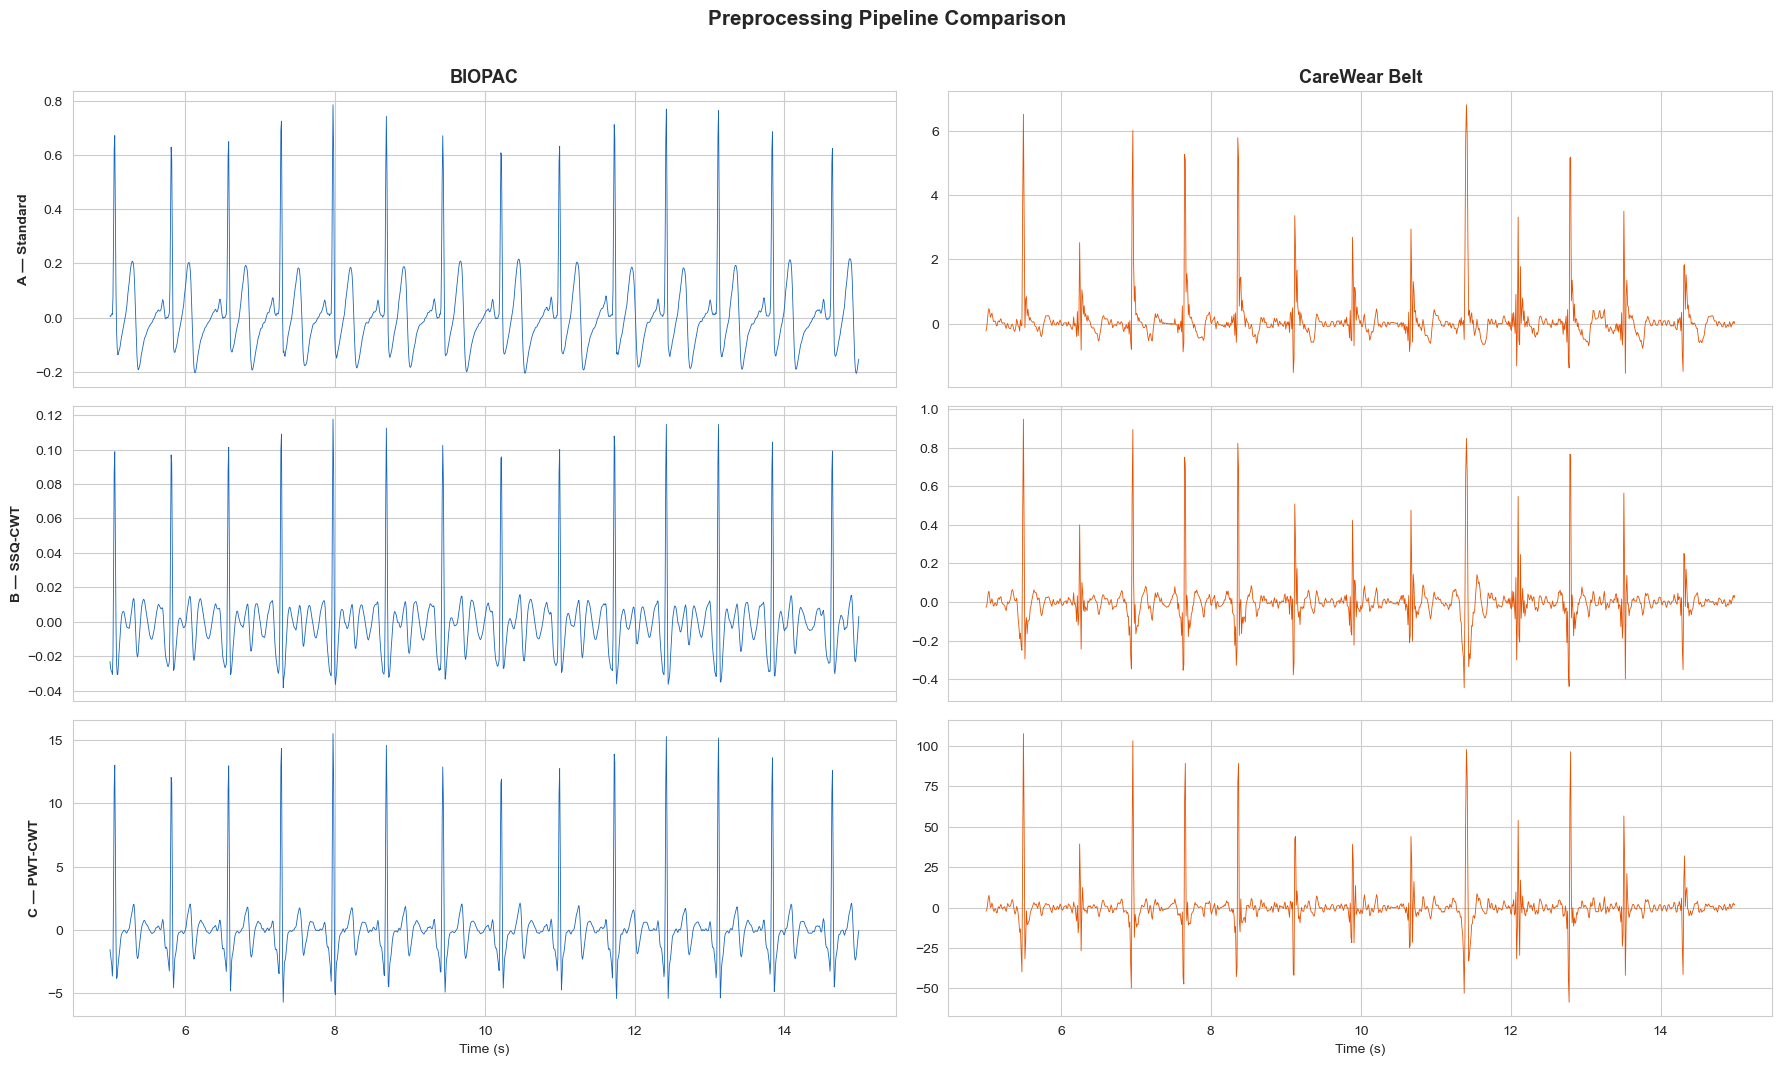

In [19]:
fig, axes = plt.subplots(len(pipelines), 2, figsize=(18, 3.5 * len(pipelines)),
                          sharex="col")

for i, (name, _) in enumerate(pipelines.items()):
    s_bp = int(VIEW_START * bp_fs)
    e_bp = int(VIEW_END * bp_fs)
    axes[i, 0].plot(bp_time[s_bp:e_bp], bp_processed[name][s_bp:e_bp],
                    linewidth=0.6, color="#1565C0")
    axes[i, 0].set_ylabel(name, fontsize=10, fontweight="bold")
    if i == 0:
        axes[i, 0].set_title("BIOPAC", fontsize=13, fontweight="bold")

    s_bl = int(VIEW_START * bl_fs)
    e_bl = int(VIEW_END * bl_fs)
    axes[i, 1].plot(bl_time[s_bl:e_bl], bl_processed[name][s_bl:e_bl],
                    linewidth=0.6, color="#E65100")
    if i == 0:
        axes[i, 1].set_title("CareWear Belt", fontsize=13, fontweight="bold")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Preprocessing Pipeline Comparison", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pipeline_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Wavelet visualization (CWT scalogram + QRS energy)

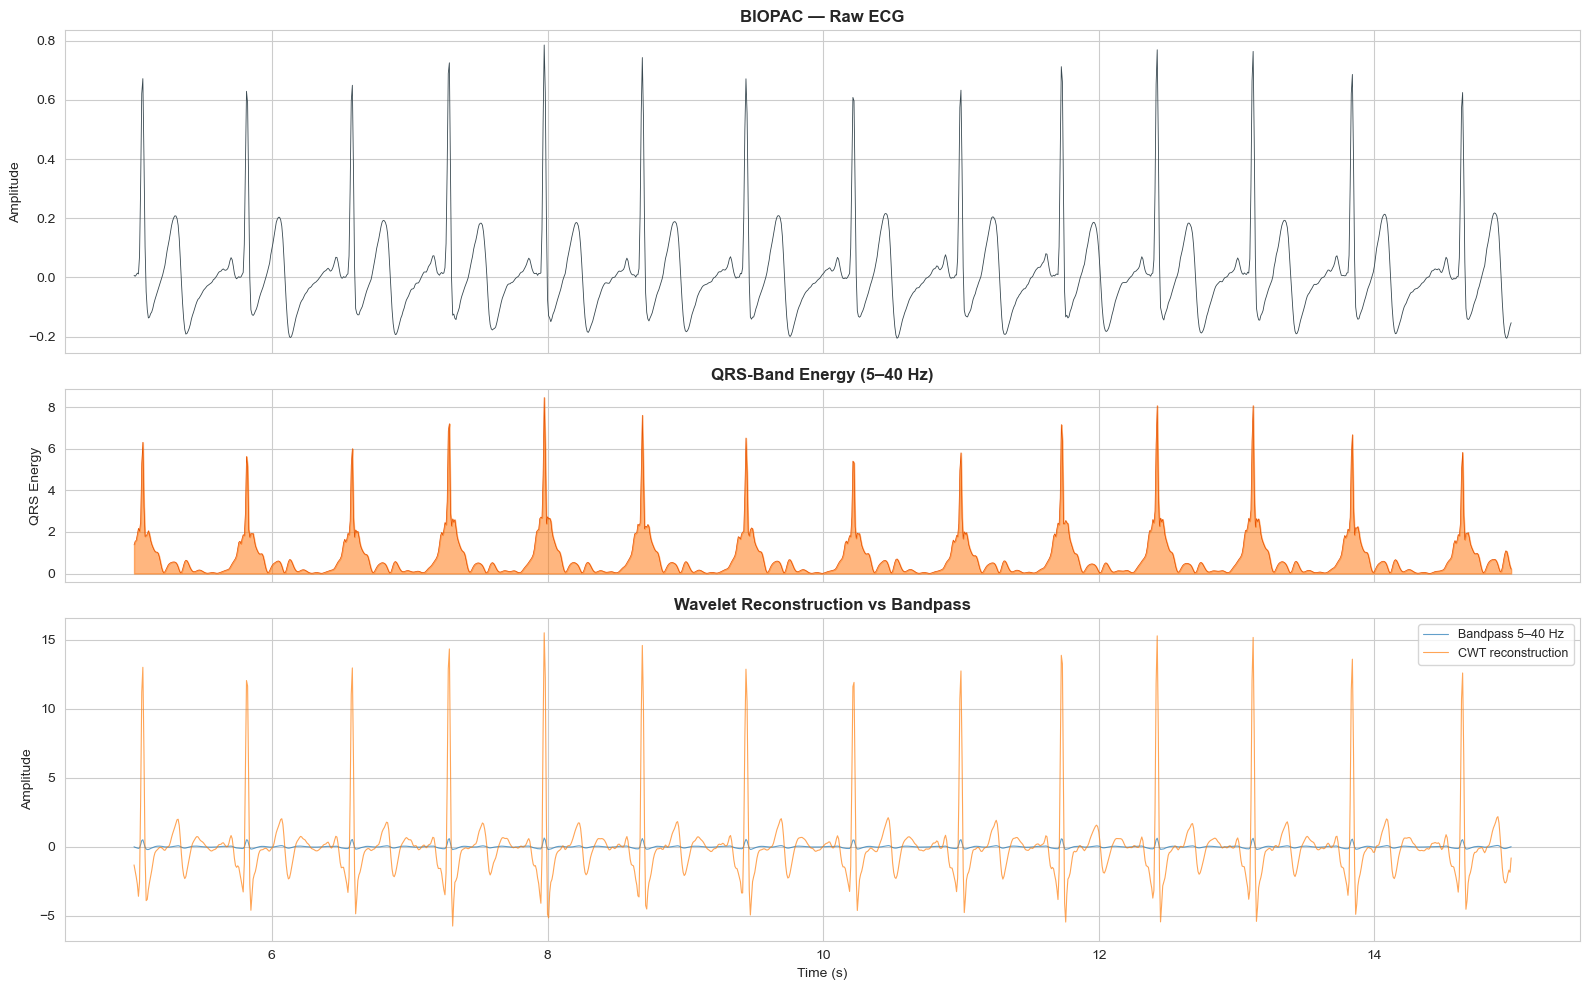

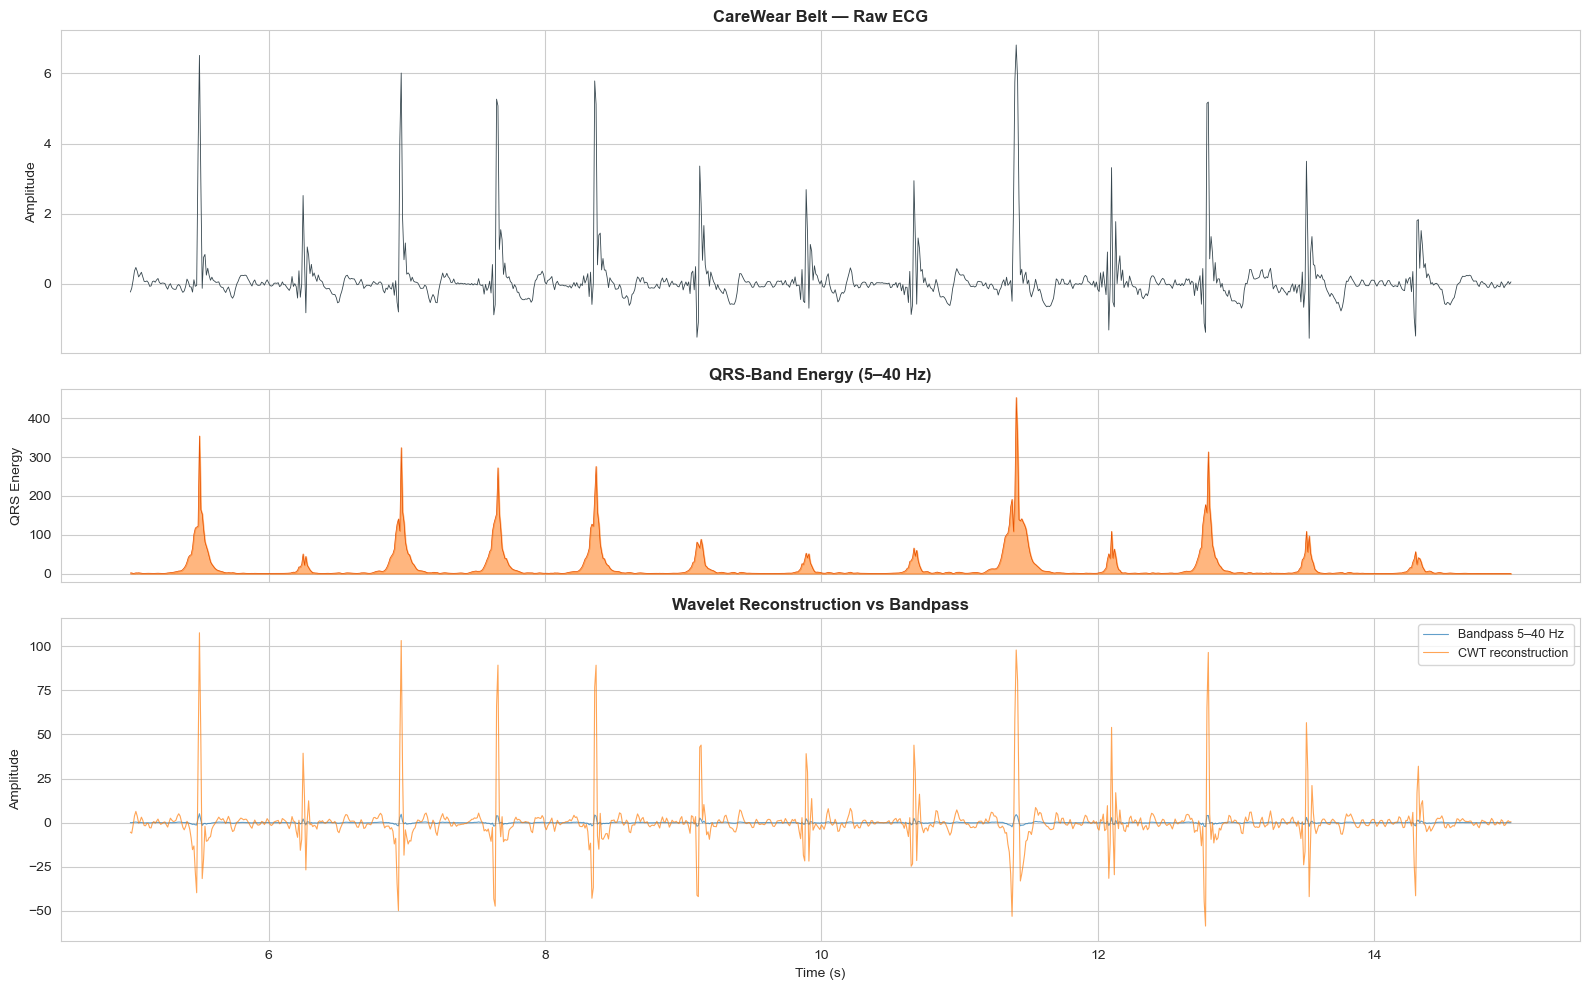

In [20]:
def plot_cwt_analysis(ecg, fs, time_arr, title, save_name):
    """3-row figure: raw ECG, QRS-band energy, wavelet reconstruction vs bandpass."""
    if not HAS_PWT:
        print(f"  [skip] pywt not installed — {title}")
        return

    seg_s, seg_e = int(VIEW_START * fs), int(VIEW_END * fs)
    sig = ecg[seg_s:seg_e]
    t = time_arr[seg_s:seg_e]

    freqs = np.arange(1, 60, 1)
    scales = pywt.frequency2scale('morl', freqs / fs)
    coeffs, cwt_freqs = pywt.cwt(sig, scales, 'morl', sampling_period=1/fs)
    power = np.abs(coeffs) ** 2

    qrs_mask = (freqs >= 5) & (freqs <= 40)
    qrs_energy = power[qrs_mask, :].sum(axis=0)

    recon_cwt = np.real(coeffs[qrs_mask, :].sum(axis=0))
    recon_bp = bandpass_filter(sig, fs, 5, 40)

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                              gridspec_kw={"height_ratios": [1, 0.6, 1]})

    axes[0].plot(t, sig, linewidth=0.6, color="#37474F")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"{title} — Raw ECG", fontweight="bold")

    axes[1].fill_between(t, qrs_energy, alpha=0.5, color="#FF6F00")
    axes[1].plot(t, qrs_energy, linewidth=0.5, color="#E65100")
    axes[1].set_ylabel("QRS Energy")
    axes[1].set_title("QRS-Band Energy (5–40 Hz)", fontweight="bold")

    axes[2].plot(t, recon_bp, label="Bandpass 5–40 Hz", linewidth=0.8, alpha=0.7)
    axes[2].plot(t, recon_cwt, label="CWT reconstruction", linewidth=0.8, alpha=0.7)
    axes[2].set_ylabel("Amplitude")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Wavelet Reconstruction vs Bandpass", fontweight="bold")
    axes[2].legend(loc="upper right", fontsize=9)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches="tight")
    plt.show()


plot_cwt_analysis(bp_processed["A — Standard"], bp_fs, bp_time,
                  "BIOPAC", "cwt_analysis_biopac.png")

plot_cwt_analysis(bl_processed["A — Standard"], bl_fs, bl_time,
                  "CareWear Belt", "cwt_analysis_belt.png")

## 7. Reference R-peaks from BIOPAC

In [21]:
bp_clean = bp_processed["A — Standard"]

try:
    _, bp_ref_info = nk.ecg_peaks(bp_clean, sampling_rate=bp_fs, method="neurokit")
    bp_ref_peaks = np.array(bp_ref_info["ECG_R_Peaks"])
except Exception:
    bp_ref_peaks = np.array([])

if "CH43" in bp_df.columns:
    ch43 = bp_df["CH43"].values
    ch43_peaks = np.where(np.diff((ch43 > 0).astype(int)) > 0)[0]
    print(f"CH43 R-wave markers: {len(ch43_peaks)} peaks")
    print(f"NeuroKit reference:  {len(bp_ref_peaks)} peaks")
else:
    print(f"BIOPAC reference: {len(bp_ref_peaks)} peaks (NeuroKit on CH{CAREWEAR_BIOPAC_ECG_COL[2:]})")

if len(bp_ref_peaks) > 1:
    rr_ms = np.diff(bp_ref_peaks) / bp_fs * 1000
    hr_bpm = 60000 / np.median(rr_ms)
    print(f"Median HR: {hr_bpm:.1f} bpm")

CH43 R-wave markers: 1 peaks
NeuroKit reference:  424 peaks
Median HR: 85.2 bpm


## 8. Evaluation helpers

In [22]:
def evaluate_rpeaks(ref_peaks, test_peaks, fs, tolerance_ms=50):
    """Beat-level evaluation: TP/FP/FN -> Se/PPV/F1 at given tolerance."""
    if len(ref_peaks) == 0 or len(test_peaks) == 0:
        return dict(TP=0, FP=len(test_peaks), FN=len(ref_peaks),
                    Se=0.0, PPV=0.0, F1=0.0)
    tol = int(tolerance_ms * fs / 1000)
    tp, fp, matched = 0, 0, set()
    for p in test_peaks:
        diffs = np.abs(ref_peaks - p)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and idx not in matched:
            tp += 1
            matched.add(idx)
        else:
            fp += 1
    fn = len(ref_peaks) - len(matched)
    se  = tp / (tp + fn + 1e-9)
    ppv = tp / (tp + fp + 1e-9)
    f1  = 2 * se * ppv / (se + ppv + 1e-9)
    return dict(TP=tp, FP=fp, FN=fn,
                Se=round(se, 4), PPV=round(ppv, 4), F1=round(f1, 4))


def rr_intervals_ms(peaks, fs):
    """Convert R-peak indices to RR intervals in ms."""
    return np.diff(peaks) / fs * 1000 if len(peaks) > 1 else np.array([])


def bland_altman(ref_rr, test_rr, ax, label="", color="#2196F3"):
    """Bland-Altman plot on given axes."""
    n = min(len(ref_rr), len(test_rr))
    r, t = ref_rr[:n], test_rr[:n]
    mean_vals = (r + t) / 2
    diff_vals = t - r
    md, sd = np.mean(diff_vals), np.std(diff_vals, ddof=1)
    ax.scatter(mean_vals, diff_vals, s=12, alpha=0.5, color=color, edgecolors="none")
    ax.axhline(md, color="black", linewidth=1)
    ax.axhline(md + 1.96*sd, color="red", linewidth=1, linestyle="--")
    ax.axhline(md - 1.96*sd, color="red", linewidth=1, linestyle="--")
    ylim = max(abs(md - 1.96*sd), abs(md + 1.96*sd)) * 1.4
    ax.set_ylim(-ylim if ylim > 0 else -50, ylim if ylim > 0 else 50)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean RR (ms)")
    ax.set_ylabel("Diff (ms)")

## 9. Multi-detector comparison (per pipeline)

In [23]:
NK2_METHODS = [
    "neurokit", "pantompkins1985", "hamilton2002", "christov2004",
    "gamboa2008", "engzeemod2012", "elgendi2010", "kalidas2017",
    "rodrigues2021",
]


def run_xqrs(ecg_signal, fs):
    if not HAS_WFDB:
        return np.array([])
    xqrs = wfdb_proc.XQRS(sig=ecg_signal, fs=fs)
    xqrs.detect()
    return np.array(xqrs.qrs_inds)


def run_all_detectors(ecg, fs, include_xqrs=True, include_promac=True):
    """Run all detectors, return {name: {peaks, time_ms}}."""
    results = {}
    for method in tqdm(NK2_METHODS, desc="NeuroKit2 detectors"):
        try:
            t0 = time.time()
            _, info = nk.ecg_peaks(ecg, sampling_rate=fs, method=method)
            elapsed = (time.time() - t0) * 1000
            results[method] = {"peaks": np.array(info["ECG_R_Peaks"]),
                               "time_ms": elapsed}
        except Exception as e:
            print(f"  [{method}] failed: {e}")

    if include_xqrs and HAS_WFDB:
        t0 = time.time()
        xp = run_xqrs(ecg, fs)
        results["XQRS"] = {"peaks": xp, "time_ms": (time.time()-t0)*1000}

    if include_promac:
        try:
            t0 = time.time()
            _, info = nk.ecg_peaks(ecg, sampling_rate=fs, method="promac")
            results["PROMAC"] = {"peaks": np.array(info["ECG_R_Peaks"]),
                                  "time_ms": (time.time()-t0)*1000}
        except Exception:
            pass

    return results

In [24]:
all_results = {}  # {pipeline_name: {"biopac": {det: {peaks, time_ms}}, "belt": {...}}}

for pipe_name in pipelines:
    print(f"\n{'='*60}")
    print(f"Pipeline: {pipe_name}")
    print(f"{'='*60}")

    print("  BIOPAC...")
    bp_det = run_all_detectors(bp_processed[pipe_name], bp_fs)

    print("  Belt...")
    bl_det = run_all_detectors(bl_processed[pipe_name], bl_fs)

    all_results[pipe_name] = {"biopac": bp_det, "belt": bl_det}

print("\nAll detectors run on all pipelines.")


Pipeline: A — Standard
  BIOPAC...


NeuroKit2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
  Belt...


NeuroKit2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.

Pipeline: B — SSQ-CWT
  BIOPAC...


...

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.

Pipeline: C — PWT-CWT
  BIOPAC...


NeuroKit2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
  Belt...


NeuroKit2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.

All detectors run on all pipelines.


### 9a. Evaluate BIOPAC detectors against reference

In [25]:
biopac_f1_scores = {}  # averaged across pipelines for weighting
eval_rows = []

for pipe_name, res in all_results.items():
    for det_name, det_data in res["biopac"].items():
        ev = evaluate_rpeaks(bp_ref_peaks, det_data["peaks"], bp_fs)
        ev["Pipeline"] = pipe_name
        ev["Detector"] = det_name
        ev["Time_ms"] = round(det_data["time_ms"], 1)
        eval_rows.append(ev)
        biopac_f1_scores.setdefault(det_name, []).append(ev["F1"])

biopac_eval_df = pd.DataFrame(eval_rows)
biopac_f1_avg = {k: np.mean(v) for k, v in biopac_f1_scores.items()}

print("BIOPAC evaluation (Pipeline A):")
display(biopac_eval_df[biopac_eval_df["Pipeline"] == "A — Standard"][
    ["Detector", "Se", "PPV", "F1", "Time_ms"]
].sort_values("F1", ascending=False).reset_index(drop=True))

BIOPAC evaluation (Pipeline A):


,Detector,Se,PPV,F1,Time_ms
0,neurokit,1.0000,1.0000,1.0000,17.8
1,kalidas2017,1.0000,1.0000,1.0000,6.4
2,engzeemod2012,1.0000,1.0000,1.0000,316.4
3,PROMAC,1.0000,0.9976,0.9988,1190.6
4,hamilton2002,1.0000,0.9976,0.9988,77.0
5,christov2004,1.0000,0.9976,0.9988,822.9
6,rodrigues2021,1.0000,0.9953,0.9976,45.0
7,elgendi2010,1.0000,0.9953,0.9976,68.9
8,XQRS,1.0000,0.9907,0.9953,102.5
9,pantompkins1985,0.7877,0.7859,0.7868,8.3


### 9b. Performance heatmap across all pipelines

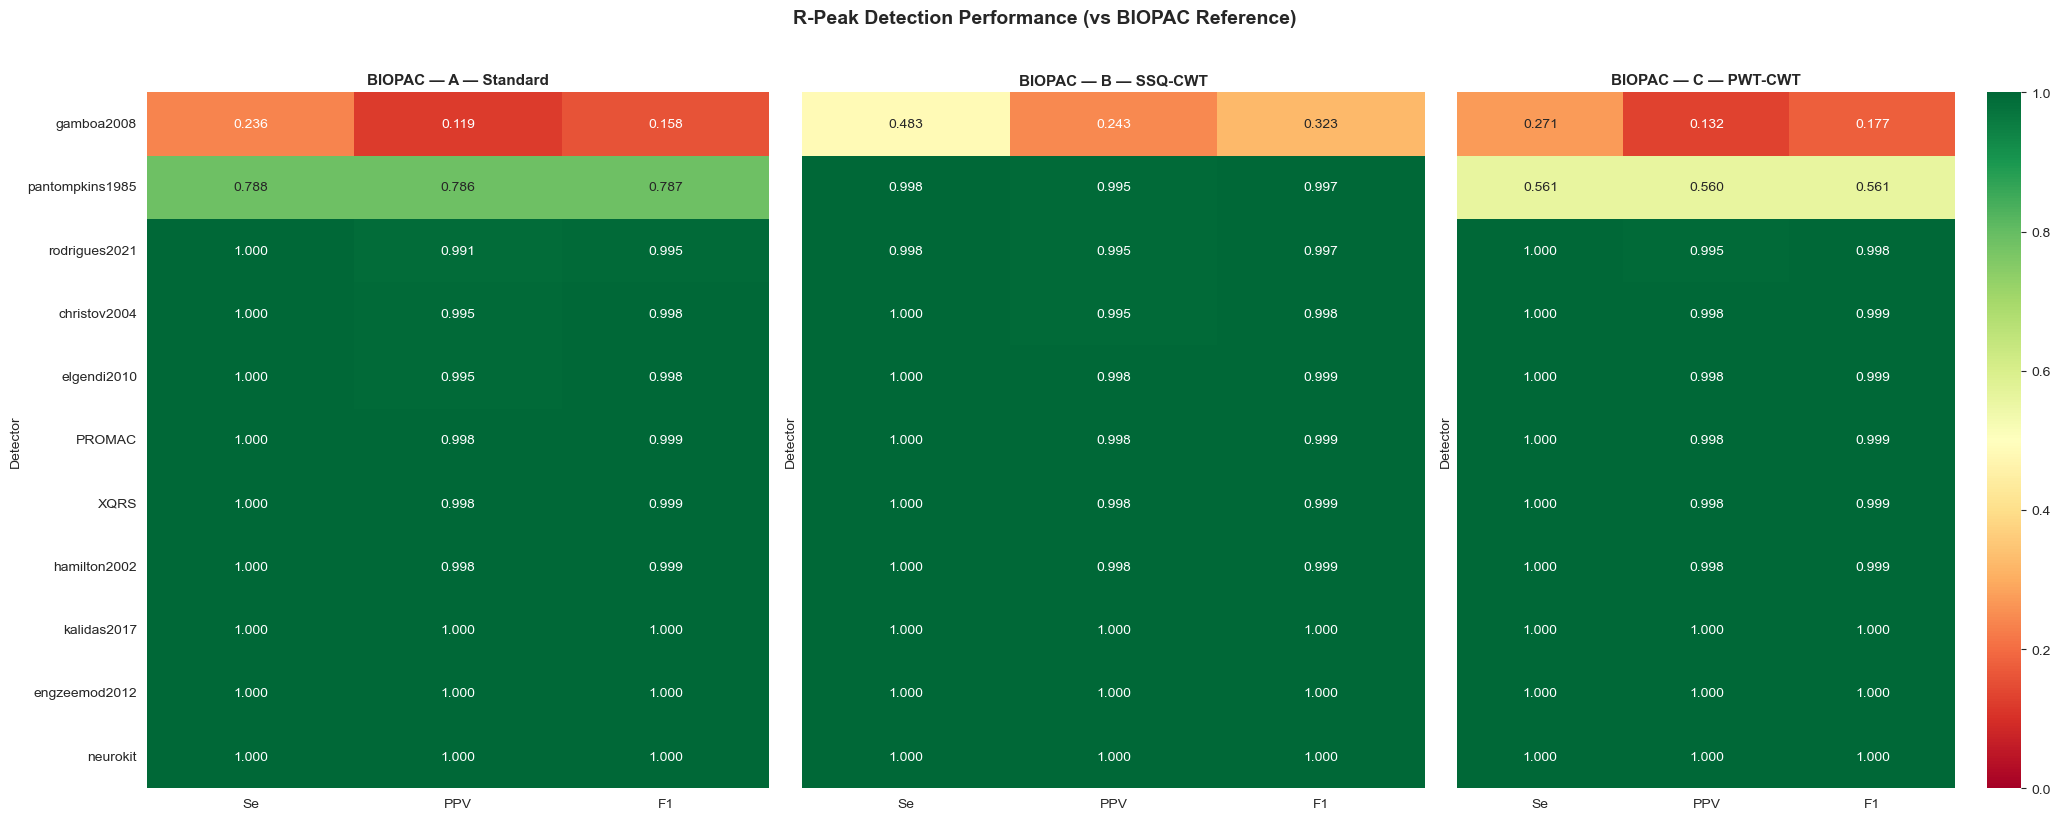

In [26]:
fig, axes = plt.subplots(1, len(pipelines), figsize=(7 * len(pipelines), 8), sharey=True)

for i, pipe_name in enumerate(pipelines):
    sub = biopac_eval_df[biopac_eval_df["Pipeline"] == pipe_name].set_index("Detector")
    vals = sub[["Se", "PPV", "F1"]].astype(float)
    vals = vals.sort_values("F1", ascending=True)
    sns.heatmap(vals, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                ax=axes[i], cbar=(i == len(pipelines)-1))
    axes[i].set_title(f"BIOPAC — {pipe_name}", fontsize=11, fontweight="bold")

fig.suptitle("R-Peak Detection Performance (vs BIOPAC Reference)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heatmap_all_pipelines.png"), dpi=150, bbox_inches="tight")
plt.show()

### 9c. R-peak overlay (best pipeline for belt)

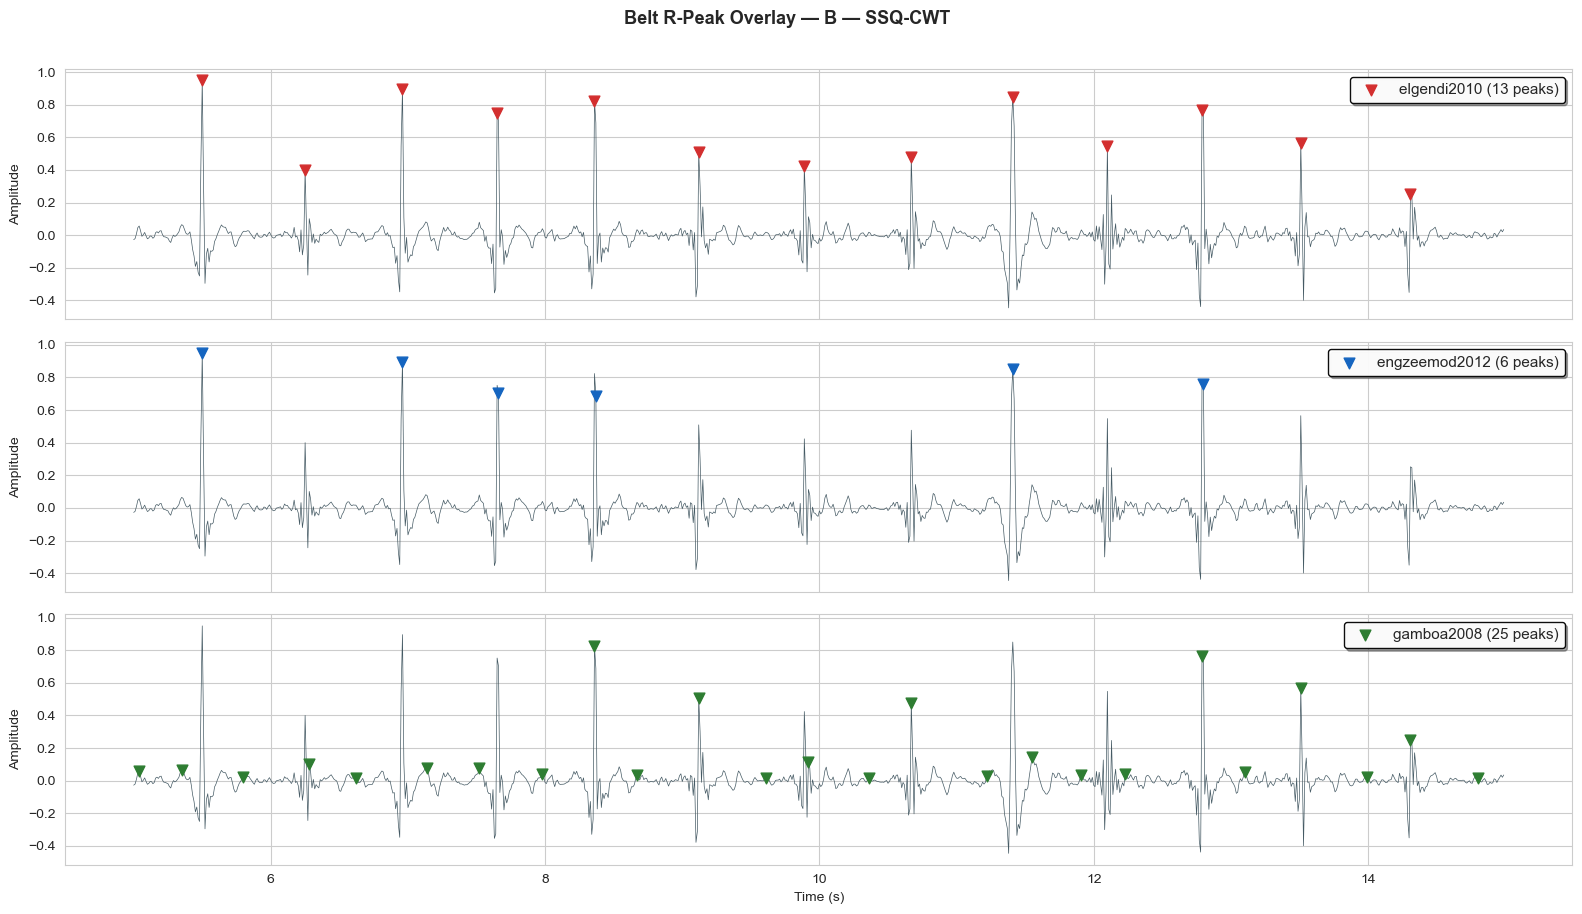

In [27]:
best_pipe = "B — SSQ-CWT" if HAS_SSQ else "A — Standard"
bl_ecg_best = bl_processed[best_pipe]
bl_dets = all_results[best_pipe]["belt"]

top3 = sorted(bl_dets.keys(), key=lambda x: len(bl_dets[x]["peaks"]))[-3:]

s, e = int(VIEW_START * bl_fs), int(VIEW_END * bl_fs)
fig, axes = plt.subplots(len(top3), 1, figsize=(16, 3 * len(top3)), sharex=True)
if len(top3) == 1:
    axes = [axes]

colors = ["#D32F2F", "#1565C0", "#2E7D32"]
for i, det_name in enumerate(top3):
    ax = axes[i]
    ax.plot(bl_time[s:e], bl_ecg_best[s:e], linewidth=0.5, color="#455A64")
    peaks = bl_dets[det_name]["peaks"]
    in_window = peaks[(peaks >= s) & (peaks < e)]
    ax.scatter(bl_time[in_window], bl_ecg_best[in_window], color=colors[i],
               s=60, zorder=5, marker="v", label=f"{det_name} ({len(in_window)} peaks)")
    ax.legend(loc="upper right", fontsize=11, framealpha=0.95,
              edgecolor="black", shadow=True)
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Belt R-Peak Overlay — {best_pipe}", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "belt_rpeak_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. RPNet AI Detector

In [28]:
if TORCH_AVAILABLE:
    class IncResBlock(nn.Module):
        def __init__(self, inplanes, planes, convstr=1, convsize=15, convpadding=7):
            super().__init__()
            self.Inputconv1x1 = nn.Conv1d(inplanes, planes, 1, 1, bias=False)
            self.conv1_1 = nn.Sequential(
                nn.Conv1d(inplanes, planes//4, convsize, convstr, convpadding),
                nn.BatchNorm1d(planes//4))
            self.conv1_2 = nn.Sequential(
                nn.Conv1d(inplanes, planes//4, 1, convstr, 0, bias=False),
                nn.BatchNorm1d(planes//4), nn.LeakyReLU(0.2),
                nn.Conv1d(planes//4, planes//4, convsize+2, convstr, convpadding+1),
                nn.BatchNorm1d(planes//4))
            self.conv1_3 = nn.Sequential(
                nn.Conv1d(inplanes, planes//4, 1, convstr, 0, bias=False),
                nn.BatchNorm1d(planes//4), nn.LeakyReLU(0.2),
                nn.Conv1d(planes//4, planes//4, convsize+4, convstr, convpadding+2),
                nn.BatchNorm1d(planes//4))
            self.conv1_4 = nn.Sequential(
                nn.Conv1d(inplanes, planes//4, 1, convstr, 0, bias=False),
                nn.BatchNorm1d(planes//4), nn.LeakyReLU(0.2),
                nn.Conv1d(planes//4, planes//4, convsize+6, convstr, convpadding+3),
                nn.BatchNorm1d(planes//4))
            self.relu = nn.ReLU()

        def forward(self, x):
            residual = self.Inputconv1x1(x)
            out = torch.cat([self.conv1_1(x), self.conv1_2(x),
                             self.conv1_3(x), self.conv1_4(x)], 1)
            return self.relu(out + residual)

    class IncUNet(nn.Module):
        def __init__(self, in_shape):
            super().__init__()
            in_channels, height, width = in_shape
            self.e1 = nn.Sequential(nn.Conv1d(in_channels,64,4,2,1), nn.BatchNorm1d(64), nn.LeakyReLU(0.2), IncResBlock(64,64))
            self.e2 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(64,128,4,2,1), nn.BatchNorm1d(128), IncResBlock(128,128))
            self.e2add = nn.Sequential(nn.Conv1d(128,128,3,1,1), nn.BatchNorm1d(128))
            self.e3 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(128,128,3,1,1), nn.BatchNorm1d(128), nn.LeakyReLU(0.2), nn.Conv1d(128,256,4,2,1), nn.BatchNorm1d(256), IncResBlock(256,256))
            self.e4 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(256,256,4,1,1), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Conv1d(256,512,4,2,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.e4add = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(512,512,3,1,1), nn.BatchNorm1d(512))
            self.e5 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(512,512,3,1,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Conv1d(512,512,4,2,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.e6 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(512,512,3,1,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Conv1d(512,512,4,2,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.e6add = nn.Sequential(nn.Conv1d(512,512,3,1,1), nn.BatchNorm1d(512))
            self.e7 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(512,512,3,1,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Conv1d(512,512,4,2,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.e8 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv1d(512,512,4,1,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Conv1d(512,512,4,2,1), nn.BatchNorm1d(512))
            self.d1 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,512,4,2,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,512,4,1,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.d2 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,512,4,2,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,512,3,1,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.d3 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,512,3,1,1), nn.BatchNorm1d(512), nn.Dropout(0.5), IncResBlock(512,512))
            self.d4 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,512,4,2,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,512,3,1,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.d5 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,512,4,2,1), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,512,3,1,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.d6 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,512,3,1,1), nn.BatchNorm1d(512), IncResBlock(512,512))
            self.d7 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(1024,256,4,2,1), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.ConvTranspose1d(256,256,4,1,1), nn.BatchNorm1d(256), IncResBlock(256,256))
            self.d8 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(512,128,4,2,1), nn.BatchNorm1d(128), nn.LeakyReLU(0.2), nn.ConvTranspose1d(128,128,3,1,1), nn.BatchNorm1d(128))
            self.d9 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(256,128,3,1,1), nn.BatchNorm1d(128))
            self.d10 = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(256,64,4,2,1), nn.BatchNorm1d(64))
            self.out_l = nn.Sequential(nn.LeakyReLU(0.2), nn.ConvTranspose1d(128,in_channels,4,2,1))

        def forward(self, x):
            en1 = self.e1(x); en2 = self.e2(en1)
            en2add = self.e2add(en2); en3 = self.e3(en2add)
            en4 = self.e4(en3); en4add = self.e4add(en4)
            en5 = self.e5(en4add); en6 = self.e6(en5)
            en6add = self.e6add(en6); en7 = self.e7(en6add)
            en8 = self.e8(en7)
            de1 = torch.cat([en7, self.d1(en8)], 1)
            de2 = torch.cat([en6add, self.d2(de1)], 1)
            de3 = torch.cat([en6, self.d3(de2)], 1)
            de4 = torch.cat([en5, self.d4(de3)], 1)
            de5 = torch.cat([en4add, self.d5(de4)], 1)
            de6 = torch.cat([en4, self.d6(de5)], 1)
            de7 = torch.cat([en3, self.d7(de6)], 1)
            de8 = torch.cat([en2add, self.d8(de7)], 1)
            de9 = torch.cat([en2, self.d9(de8)], 1)
            de10 = torch.cat([en1, self.d10(de9)], 1)
            return self.out_l(de10)

In [29]:
def load_rpnet_model(model_dir, weights_file, device="cpu"):
    model = IncUNet((1, 1, 5000)).to(device)
    path = os.path.join(model_dir, weights_file)
    if not os.path.exists(path):
        print(f"  [RPNet] Weights not found: {path}")
        return None
    sd = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(sd, strict=False)
    model.eval()
    print(f"  RPNet loaded ({sum(p.numel() for p in model.parameters()):,} params)")
    return model


def rpnet_inference_windowed(signal_500hz, model, device="cpu",
                              window_samples=5000, stride=2500):
    """Sliding-window RPNet inference at 500 Hz. Returns (distance_map, peak_indices)."""
    N = len(signal_500hz)
    distance_map = np.zeros(N)
    weight_map = np.zeros(N)

    starts = list(range(0, max(1, N - window_samples + 1), stride))
    if starts[-1] + window_samples < N:
        starts.append(N - window_samples)

    for s in tqdm(starts, desc="RPNet inference"):
        seg = signal_500hz[s:s + window_samples].copy()
        mu, sigma = seg.mean(), seg.std() + 1e-9
        seg = (seg - mu) / sigma
        inp = torch.tensor(seg, dtype=torch.float32).reshape(1, 1, -1).to(device)
        with torch.no_grad():
            out = model(inp)
        dt = out.cpu().numpy().flatten()[:window_samples]
        distance_map[s:s+window_samples] += dt
        weight_map[s:s+window_samples] += 1

    weight_map = np.maximum(weight_map, 1)
    distance_map /= weight_map

    inv_dt = -distance_map
    dt_range = np.ptp(distance_map)
    prom = max(0.1, 0.15 * dt_range)
    r_peaks, _ = find_peaks(inv_dt, distance=int(0.3 * 500), prominence=prom)
    return distance_map, r_peaks


rpnet_model = None
if TORCH_AVAILABLE:
    rpnet_model = load_rpnet_model(RPNET_MODEL_DIR, RPNET_WEIGHTS, DEVICE)

  [RPNet] Weights not found: reference_codes/RPNet\model.pth


In [30]:
rpnet_results = {}

if rpnet_model is not None:
    for src_name, (ecg_raw, fs_raw) in [("BIOPAC", (bp_processed["A — Standard"], bp_fs)),
                                         ("Belt",   (bl_processed[best_pipe], bl_fs))]:
        g = gcd(500, fs_raw)
        ecg_500 = resample_poly(ecg_raw, 500 // g, fs_raw // g)

        t0 = time.time()
        dt_map, peaks_500 = rpnet_inference_windowed(ecg_500, rpnet_model, DEVICE)
        elapsed = (time.time() - t0) * 1000

        peaks_orig = np.round(peaks_500 * fs_raw / 500).astype(int)
        peaks_orig = peaks_orig[peaks_orig < len(ecg_raw)]

        rpnet_results[src_name] = {
            "peaks_500": peaks_500, "peaks_orig": peaks_orig,
            "dt_map": dt_map, "ecg_500": ecg_500,
            "time_ms": elapsed
        }
        print(f"  {src_name} RPNet: {len(peaks_orig)} peaks in {elapsed:.0f} ms")
else:
    print("RPNet skipped (model not loaded).")

RPNet skipped (model not loaded).


### 10a. Distance transform visualization

In [31]:
if rpnet_results:
    for src_name, rr in rpnet_results.items():
        t500 = np.arange(len(rr["ecg_500"])) / 500.0
        mask = (t500 >= VIEW_START) & (t500 <= VIEW_END)

        fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
        axes[0].plot(t500[mask], rr["ecg_500"][mask], linewidth=0.5, color="#37474F")
        pw = rr["peaks_500"][(rr["peaks_500"] >= np.where(mask)[0][0]) &
                              (rr["peaks_500"] <= np.where(mask)[0][-1])]
        axes[0].scatter(t500[pw], rr["ecg_500"][pw], color="red", s=50, zorder=5, marker="v")
        axes[0].set_title(f"{src_name} — ECG @ 500 Hz + RPNet peaks", fontweight="bold")
        axes[0].set_ylabel("Amplitude")

        axes[1].plot(t500[mask], rr["dt_map"][mask], linewidth=0.5, color="#1565C0")
        axes[1].set_title("Distance Transform", fontweight="bold")
        axes[1].set_ylabel("DT value")
        axes[1].set_xlabel("Time (s)")

        fig.tight_layout()
        fig.savefig(os.path.join(OUTPUT_DIR, f"rpnet_dt_{src_name.lower()}.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

## 11. Signal Quality Index (SQI)

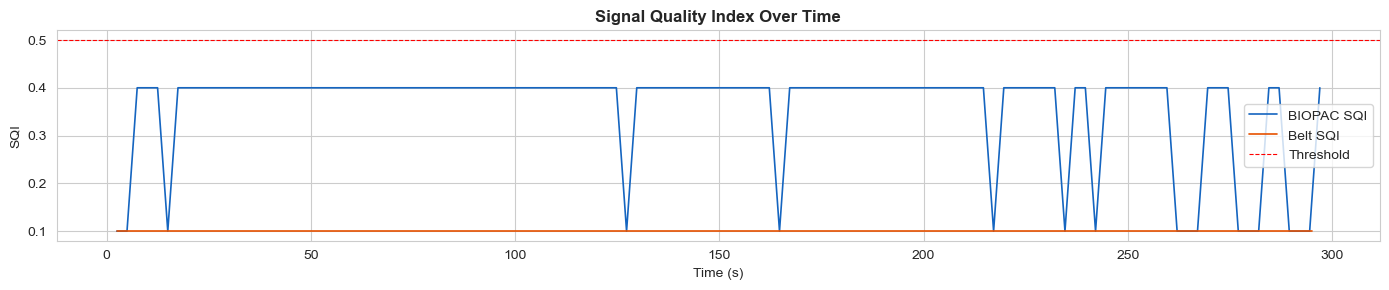

In [32]:
def compute_kurtosis_sqi(signal, fs, window_s=5, stride_s=2.5):
    """Windowed kurtosis SQI. High kurtosis (>5) suggests artifacts."""
    win = int(window_s * fs)
    stride = int(stride_s * fs)
    vals, times = [], []
    for s in range(0, len(signal) - win, stride):
        k = kurtosis(signal[s:s+win], fisher=True)
        if k > 8:   sqi = 0.1
        elif k > 5: sqi = 0.4
        elif k > 3: sqi = 0.7
        else:       sqi = 1.0
        vals.append(sqi)
        times.append((s + win/2) / fs)
    return np.array(vals), np.array(times)


bl_sqi_vals, bl_sqi_times = compute_kurtosis_sqi(bl_processed[best_pipe], bl_fs)
bp_sqi_vals, bp_sqi_times = compute_kurtosis_sqi(bp_clean, bp_fs)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(bp_sqi_times, bp_sqi_vals, label="BIOPAC SQI", linewidth=1.2, color="#1565C0")
ax.plot(bl_sqi_times, bl_sqi_vals, label="Belt SQI", linewidth=1.2, color="#E65100")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Threshold")
ax.set_ylabel("SQI"); ax.set_xlabel("Time (s)")
ax.set_title("Signal Quality Index Over Time", fontweight="bold")
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "sqi_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Consensus fusion

In [33]:
def biopac_weighted_consensus(detector_peaks_dict, detector_scores_dict,
                               signal_length, fs, sigma_ms=50):
    """Gaussian-weighted consensus from multiple detectors.

    Each detector's binary spike train is convolved with a Gaussian
    kernel, weighted by its BIOPAC F1 score, then summed.
    """
    sigma = int(sigma_ms * fs / 1000)
    total_weight = sum(detector_scores_dict.values()) + 1e-9
    prob = np.zeros(signal_length)

    for name, peaks in tqdm(detector_peaks_dict.items(), desc="Building consensus"):
        w = detector_scores_dict.get(name, 0.5) / total_weight
        binary = np.zeros(signal_length)
        valid = peaks[(peaks >= 0) & (peaks < signal_length)].astype(int)
        binary[valid] = 1
        prob += w * gaussian_filter1d(binary.astype(float), sigma)

    if prob.max() > 0:
        prob /= prob.max()
    final, _ = find_peaks(prob, height=0.4 * prob.max(), distance=int(0.3 * fs))
    return final, prob


def sqi_gated_detector(ecg, fs, sqi_values, sqi_times, sqi_threshold=0.5,
                        detector_peaks_dict=None, detector_scores_dict=None):
    """High-SQI: single fast detector. Low-SQI: weighted ensemble. Merge."""
    strategy_map = np.zeros(len(ecg))
    for t, sqi in zip(sqi_times, sqi_values):
        half_win = int(2.5 * fs)
        center = int(t * fs)
        s, e = max(0, center-half_win), min(len(ecg), center+half_win)
        if sqi < sqi_threshold:
            strategy_map[s:e] = 1

    try:
        _, fast_info = nk.ecg_peaks(ecg, sampling_rate=fs, method="neurokit")
        fast_peaks = np.array(fast_info["ECG_R_Peaks"])
    except Exception:
        fast_peaks = np.array([])

    if detector_peaks_dict and detector_scores_dict:
        ensemble_peaks, _ = biopac_weighted_consensus(
            detector_peaks_dict, detector_scores_dict, len(ecg), fs)
    else:
        ensemble_peaks = fast_peaks

    final = []
    for p in fast_peaks:
        if 0 <= p < len(strategy_map) and strategy_map[p] == 0:
            final.append(p)
    for p in ensemble_peaks:
        if 0 <= p < len(strategy_map) and strategy_map[p] == 1:
            final.append(p)

    final = np.sort(np.unique(final))
    if len(final) > 1:
        min_sep = int(0.2 * fs)
        keep = [final[0]]
        for p in final[1:]:
            if p - keep[-1] >= min_sep:
                keep.append(p)
        final = np.array(keep)
    return final, strategy_map

In [34]:
belt_det_peaks = {k: v["peaks"] for k, v in all_results[best_pipe]["belt"].items()}

print("=== BIOPAC-Weighted Consensus ===")
consensus_peaks, consensus_prob = biopac_weighted_consensus(
    belt_det_peaks, biopac_f1_avg,
    signal_length=len(bl_processed[best_pipe]), fs=bl_fs)
print(f"Consensus peaks: {len(consensus_peaks)}")

print("\n=== SQI-Gated Detection ===")
sqi_peaks, strategy_map = sqi_gated_detector(
    bl_processed[best_pipe], bl_fs,
    bl_sqi_vals, bl_sqi_times, sqi_threshold=0.5,
    detector_peaks_dict=belt_det_peaks,
    detector_scores_dict=biopac_f1_avg)
pct_ensemble = np.mean(strategy_map == 1) * 100
print(f"SQI-gated peaks:  {len(sqi_peaks)}")
print(f"Low-quality %:    {pct_ensemble:.1f}%")

=== BIOPAC-Weighted Consensus ===


Building consensus:   0%|          | 0/11 [00:00<?, ?it/s]

Consensus peaks: 424

=== SQI-Gated Detection ===


Building consensus:   0%|          | 0/11 [00:00<?, ?it/s]

SQI-gated peaks:  424
Low-quality %:    99.3%


### 12a. Consensus overlay

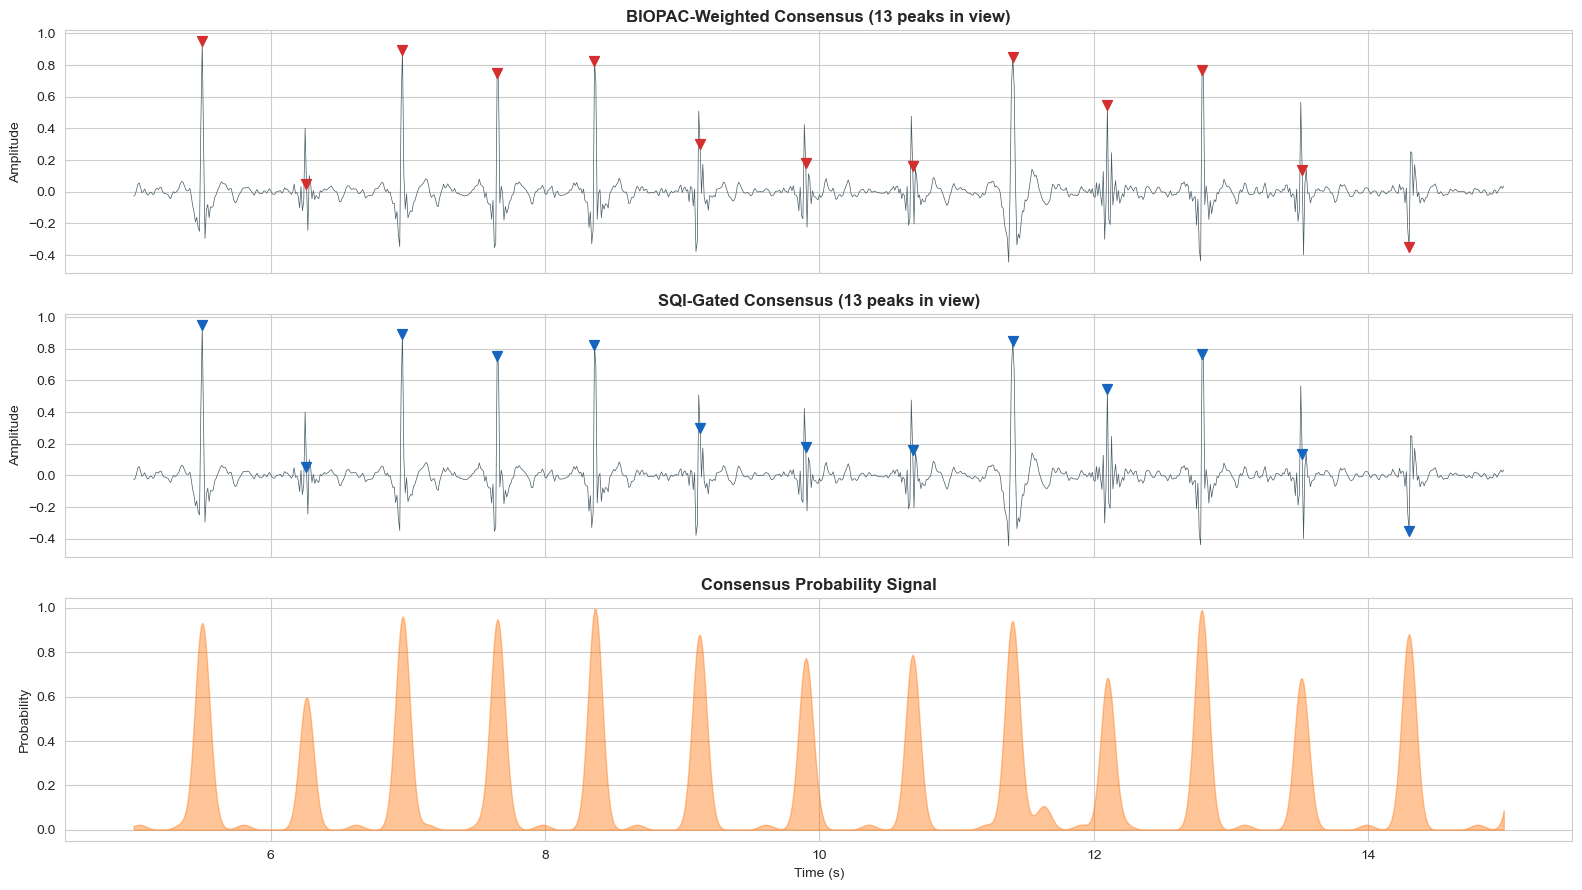

In [35]:
ecg_show = bl_processed[best_pipe]
s, e = int(VIEW_START * bl_fs), int(VIEW_END * bl_fs)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(bl_time[s:e], ecg_show[s:e], linewidth=0.5, color="#455A64")
cp = consensus_peaks[(consensus_peaks >= s) & (consensus_peaks < e)]
axes[0].scatter(bl_time[cp], ecg_show[cp], color="#D32F2F", s=50, zorder=5, marker="v")
axes[0].set_title(f"BIOPAC-Weighted Consensus ({len(cp)} peaks in view)", fontweight="bold")
axes[0].set_ylabel("Amplitude")

axes[1].plot(bl_time[s:e], ecg_show[s:e], linewidth=0.5, color="#455A64")
sp = sqi_peaks[(sqi_peaks >= s) & (sqi_peaks < e)]
axes[1].scatter(bl_time[sp], ecg_show[sp], color="#1565C0", s=50, zorder=5, marker="v")
axes[1].set_title(f"SQI-Gated Consensus ({len(sp)} peaks in view)", fontweight="bold")
axes[1].set_ylabel("Amplitude")

axes[2].fill_between(bl_time[s:e], consensus_prob[s:e], alpha=0.4, color="#FF6F00")
axes[2].set_title("Consensus Probability Signal", fontweight="bold")
axes[2].set_ylabel("Probability")
axes[2].set_xlabel("Time (s)")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "consensus_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Final summary table — all methods across all pipelines

In [36]:
summary_rows = []

for pipe_name in pipelines:
    bp_dets = all_results[pipe_name]["biopac"]
    for det_name, det_data in bp_dets.items():
        ev = evaluate_rpeaks(bp_ref_peaks, det_data["peaks"], bp_fs)
        summary_rows.append({
            "Source": "BIOPAC", "Pipeline": pipe_name,
            "Method": det_name, **ev, "Time_ms": round(det_data["time_ms"], 1)
        })

if rpnet_results.get("BIOPAC"):
    ev = evaluate_rpeaks(bp_ref_peaks, rpnet_results["BIOPAC"]["peaks_orig"], bp_fs)
    summary_rows.append({
        "Source": "BIOPAC", "Pipeline": "RPNet",
        "Method": "RPNet", **ev,
        "Time_ms": round(rpnet_results["BIOPAC"]["time_ms"], 1)
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 80)
print("FINAL SUMMARY — All Methods on BIOPAC")
print("=" * 80)
display(summary_df.sort_values(["Pipeline", "F1"], ascending=[True, False])[
    ["Pipeline", "Method", "Se", "PPV", "F1", "Time_ms"]
].reset_index(drop=True))

FINAL SUMMARY — All Methods on BIOPAC


,Pipeline,Method,Se,PPV,F1,Time_ms
0,A — Standard,neurokit,1.0000,1.0000,1.0000,17.8
1,A — Standard,engzeemod2012,1.0000,1.0000,1.0000,316.4
2,A — Standard,kalidas2017,1.0000,1.0000,1.0000,6.4
3,A — Standard,hamilton2002,1.0000,0.9976,0.9988,77.0
4,A — Standard,christov2004,1.0000,0.9976,0.9988,822.9
5,A — Standard,PROMAC,1.0000,0.9976,0.9988,1190.6
6,A — Standard,elgendi2010,1.0000,0.9953,0.9976,68.9
7,A — Standard,rodrigues2021,1.0000,0.9953,0.9976,45.0
8,A — Standard,XQRS,1.0000,0.9907,0.9953,102.5
9,A — Standard,pantompkins1985,0.7877,0.7859,0.7868,8.3


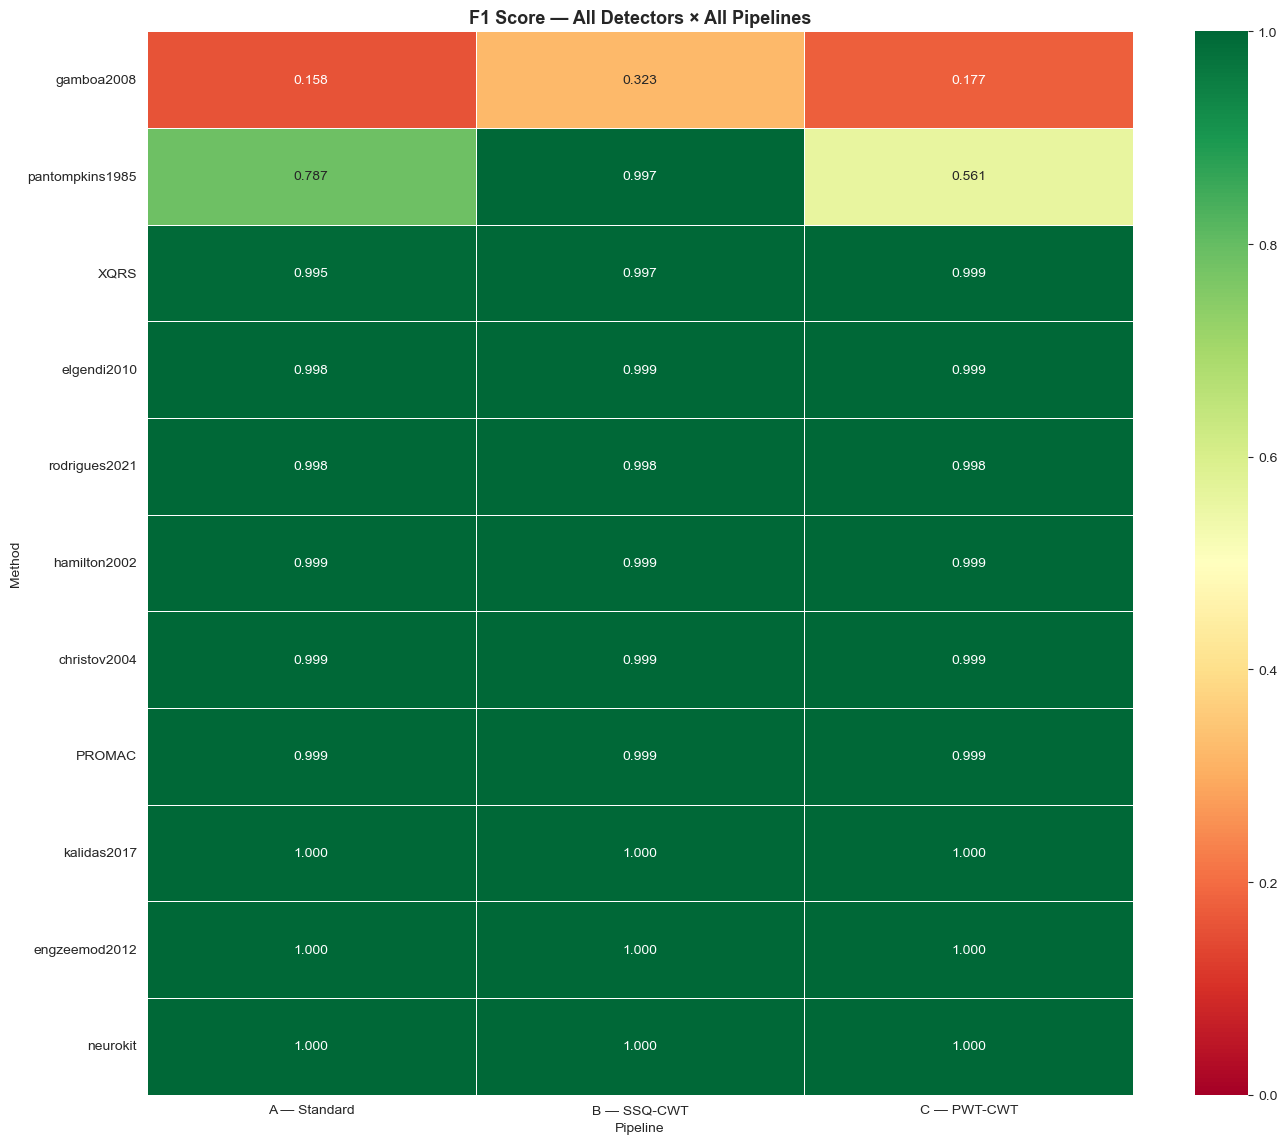


All outputs saved to: C:\Users\viggi\Documents\Github\WBL-ECG-processing_workshop\outputs\NB00


In [37]:
fig, ax = plt.subplots(figsize=(14, max(6, len(summary_df) * 0.35)))
pivot = summary_df.pivot_table(index="Method", columns="Pipeline",
                                values="F1", aggfunc="first")
pivot = pivot.sort_values(pivot.columns[0], ascending=True)
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title("F1 Score — All Detectors × All Pipelines", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "final_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nAll outputs saved to:", os.path.abspath(OUTPUT_DIR))

## 14. Takeaways

| Insight | Detail |
|---------|--------|
| **Pipeline B (SSQ-CWT)** often improves belt F1 | Wavelet band reconstruction suppresses out-of-band noise that confuses derivative-based detectors |
| **BIOPAC weighting** transfers knowledge | Detectors that perform well on clean data get higher votes on noisy data |
| **SQI gating** is a practical safety net | Switches from fast single detector to full ensemble only in degraded segments |
| **RPNet** provides a complementary view | Distance-transform peaks are found differently from threshold-based methods; useful as a tiebreaker |
| **MAX30003 decode** recovers true millivolts | Without stripping ETAG bits, the raw ADC values contain 6 bits of noise floor |

---

*End of consolidated analysis.*